# Exploratory Data Analysis

This notebook analyzes the conversation-level dataset created in the previous feature engineering step. The goal is to inspect data quality, understand the distributions of key prompt-level features and targets, and identify modelling-relevant patterns.

## Analysis Structure

The notebook is organized into the following sections:

1. Imports and configuration
2. Data loading
3. Feature groups
4. Data audit
5. Sanity checks
6. Numerical distributions
7. Categorical distributions
8. Target analysis
9. Topic analysis
10. EDA takeaways

## Focus

The analysis focuses primarily on prompt-level features that describe prompt length, instruction structure, task framing, and prompt quality. High-cardinality topic labels are analyzed separately to keep the notebook interpretable.

In [94]:
# ----------------------------
# IMPORTS + CONFIG
# ----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_ROOT = Path.cwd().parent

CONFIG = {
    "features_dir": PROJECT_ROOT / "01_data" / "03_features",
    "input_file": "conversation_dataframe.csv",
    "random_state": 42,
}

In [95]:
# ----------------------------
# LOAD DATA
# ----------------------------

INPUT_PATH = CONFIG["features_dir"] / CONFIG["input_file"]

df = pd.read_csv(INPUT_PATH)

print("Input path:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())
print("Shape:", df.shape)

df.head()

Input path: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\conversation_dataframe.csv
Exists: True
Shape: (54444, 28)


,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_prompts,follow_up_prompts,needs_follow_up,total_user_tokens,total_assistant_tokens,total_tokens,log_total_tokens,has_role_instruction,has_audience_or_level_instruction,has_format_instruction,question_count,prompt_style,task_type,orthographic_error_rate,is_valid_prompt,topic,topic_prob,embedding_novelty,target_cost,target_success,topic_label
0,QWJhYvA,Summarize the main ideas of Jeff Walker's Product Launch Formula into bullet points as it pertains to a growth marke...,<div><p>Here are the main ideas of Jeff Walker's Product Launch Formula that can be applied by a growth marketing ag...,34,304,12,6.00,6,5,1,147,2034,2181,7.69,0,0,1,0,instruction,summarization,0.00,1,0,0.45,0.56,304,1,0_dan_chatgpt_mode_prompt_developer
1,i6IyJda,How to tell if a customer segment is well segmented? In 3 bullet points.,"<div class=""markdown prose w-full break-words dark:prose-invert light""><ol><li><p>Homogeneity: The segment should co...",17,113,2,1.00,1,0,0,17,113,130,4.88,0,0,1,1,question,general_assistance,0.00,1,0,0.46,0.79,113,1,0_dan_chatgpt_mode_prompt_developer
2,A5AbcES,"In Java, I want to replace string like ""This is a new {object} at {place}"" with a Map, {object: ""student"", ""point 3,...","<div class=""markdown prose w-full break-words dark:prose-invert light""><p>You can use the <code>String.format()</cod...",62,1468,2,1.00,1,0,0,62,1468,1530,7.33,0,0,0,1,question,coding,0.00,1,-1,0.10,0.96,1468,1,-1_like_data_use_write_time
3,hRPPgZT,Metaphorical language is also used to describe the various addressing modes of the instructions. Grandiose language ...,<div><p>Metaphorical language has been summoned to describe the many enigmatic addressing modes of the instructions ...,90,132,22,11.00,11,10,1,295,4979,5274,8.57,0,0,0,0,other,writing_generation,0.07,1,23,0.14,0.72,132,1,23_word_words_letters_guess_letter
4,KXxu9my,The following is the job of the hosting service team. Assign the roles and responsibilities of the person responsibl...,"<div class=""markdown prose w-full break-words dark:prose-invert light""><table><thead><tr><th>Role</th><th>Responsibi...",507,1014,10,5.00,5,4,1,861,19855,20716,9.94,0,0,0,0,other,coding,0.02,1,0,1.00,0.60,1014,1,0_dan_chatgpt_mode_prompt_developer


In [96]:
# ----------------------------
# FEATURE GROUPS
# ----------------------------

central_features = [
    "first_prompt_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "topic_prob", 
    "embedding_novelty",
]

high_cardinality_features = [
    "topic_label",
]

target_features = [
    "target_cost",
    "target_success",
]

numeric_features = [
    "first_prompt_tokens",
    "question_count",
    "orthographic_error_rate",
    "target_cost",
    "topic_prob", 
    "embedding_novelty",
]

binary_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "target_success",
]

categorical_features = [
    "prompt_style",
    "task_type",
]

id_text_columns = [
    "conversation_id",
    "first_prompt",
    "first_response",
]

print("Central features:", central_features)
print("High-cardinality features:", high_cardinality_features)
print("Target features:", target_features)

Central features: ['first_prompt_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'topic_prob', 'embedding_novelty']
High-cardinality features: ['topic_label']
Target features: ['target_cost', 'target_success']


In [97]:
# ----------------------------
# DATA AUDIT
# ----------------------------

print("Rows, columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate conversation_id:", df["conversation_id"].duplicated().sum())

Rows, columns: (54444, 28)

Columns:
['conversation_id', 'first_prompt', 'first_response', 'first_prompt_tokens', 'first_response_tokens', 'total_turns', 'interaction_rounds', 'total_user_prompts', 'follow_up_prompts', 'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens', 'total_tokens', 'log_total_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'is_valid_prompt', 'topic', 'topic_prob', 'embedding_novelty', 'target_cost', 'target_success', 'topic_label']

Data types:


conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_prompts                     int64
follow_up_prompts                      int64
needs_follow_up                        int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
is_valid_prompt                        int64
topic     


Missing values:


conversation_id                      0
first_prompt                         0
first_response                       0
first_prompt_tokens                  0
first_response_tokens                0
total_turns                          0
interaction_rounds                   0
total_user_prompts                   0
follow_up_prompts                    0
needs_follow_up                      0
total_user_tokens                    0
total_assistant_tokens               0
total_tokens                         0
log_total_tokens                     0
has_role_instruction                 0
has_audience_or_level_instruction    0
has_format_instruction               0
question_count                       0
prompt_style                         0
task_type                            0
orthographic_error_rate              0
is_valid_prompt                      0
topic                                0
topic_prob                           0
embedding_novelty                    0
target_cost              


Duplicate rows: 0
Duplicate conversation_id: 0


In [98]:
# ----------------------------
# SANITY CHECKS
# ----------------------------

print("Prompt style values:")
display(df["prompt_style"].value_counts(dropna=False))

print("\nTask type values:")
display(df["task_type"].value_counts(dropna=False).head(20))

print("\nTarget success values:")
display(df["target_success"].value_counts(dropna=False))

print("\nNumeric plausibility checks:")
display(
    df[
        [
            "first_prompt_tokens",
            "first_response_tokens",
            "total_turns",
            "question_count",
            "orthographic_error_rate",
            "target_cost",
        ]
    ].describe().T
)

Prompt style values:


prompt_style
other          26175
question       19672
instruction     8597
Name: count, dtype: int64


Task type values:


task_type
general_assistance    22040
writing_generation    10305
coding                 9524
explanation            5204
brainstorming          2132
email_writing          1519
translation            1347
summarization          1279
roleplay               1094
Name: count, dtype: int64


Target success values:


target_success
1    52039
0     2405
Name: count, dtype: int64


Numeric plausibility checks:


,count,mean,std,min,25%,50%,75%,max
first_prompt_tokens,54444.00,171.65,814.53,2.00,16.00,34.00,108.00,79821.00
first_response_tokens,54444.00,494.63,919.48,1.00,155.00,329.00,580.00,76828.00
total_turns,54444.00,16.77,36.75,2.00,2.00,6.00,16.00,972.00
question_count,54444.00,0.60,3.01,0.00,0.00,0.00,1.00,261.00
orthographic_error_rate,54444.00,0.05,0.07,0.00,0.00,0.02,0.08,1.00
target_cost,54444.00,494.63,919.48,1.00,155.00,329.00,580.00,76828.00


## Numerical Distributions

This section explores the distributions of core numeric prompt-level features and the main cost target. The goal is to identify skewness, outliers, and scale differences that may matter for modelling.

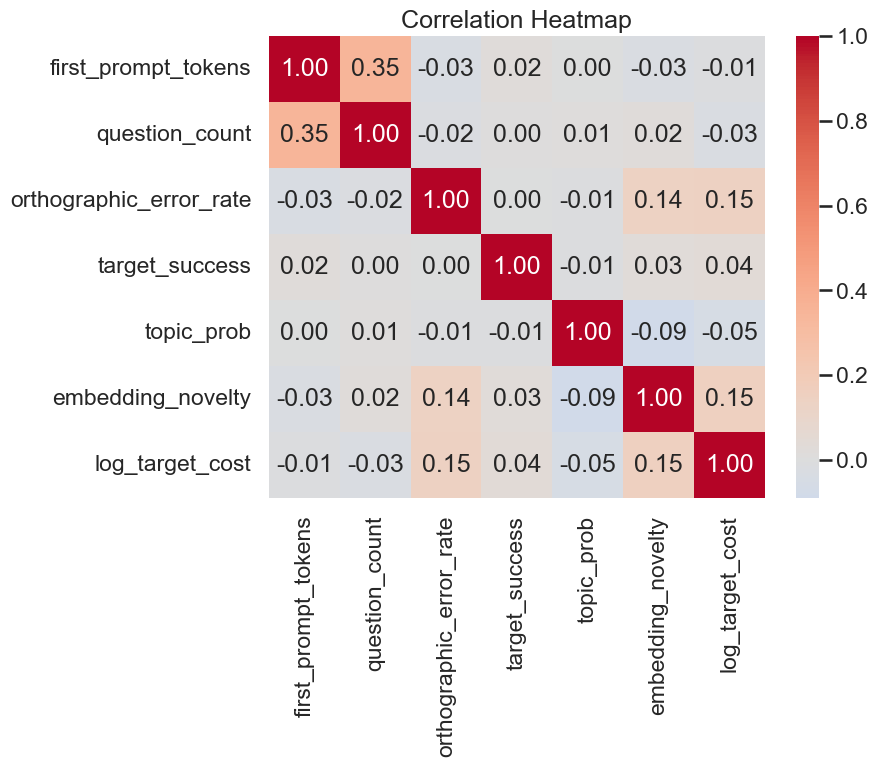

In [100]:
# ----------------------------
# CORRELATIONS
# ----------------------------

df["log_target_cost"] = np.log1p(df["target_cost"])


numeric_for_corr = [
    "first_prompt_tokens",
    "question_count",
    "orthographic_error_rate",
    "target_success",
    "topic_prob", 
    "embedding_novelty",
    "log_target_cost",
]

corr = df[numeric_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

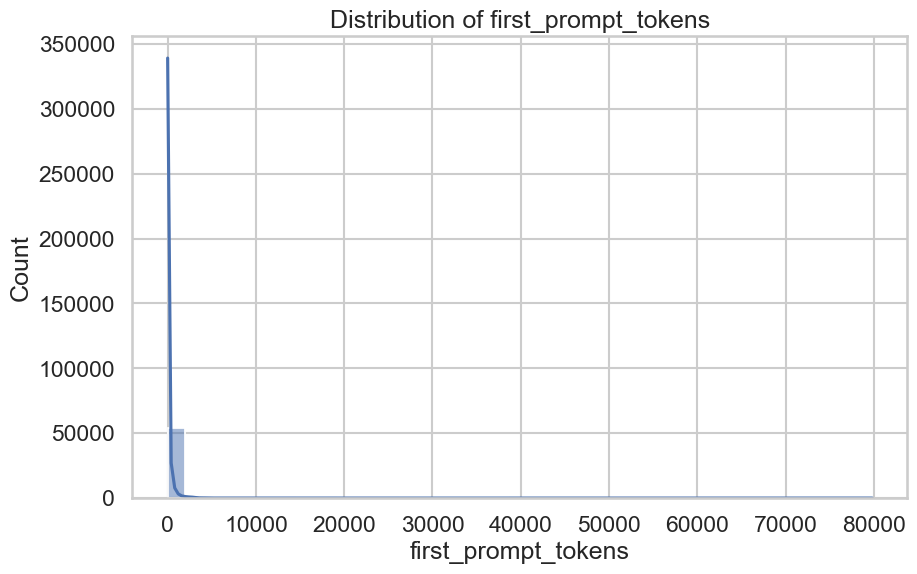

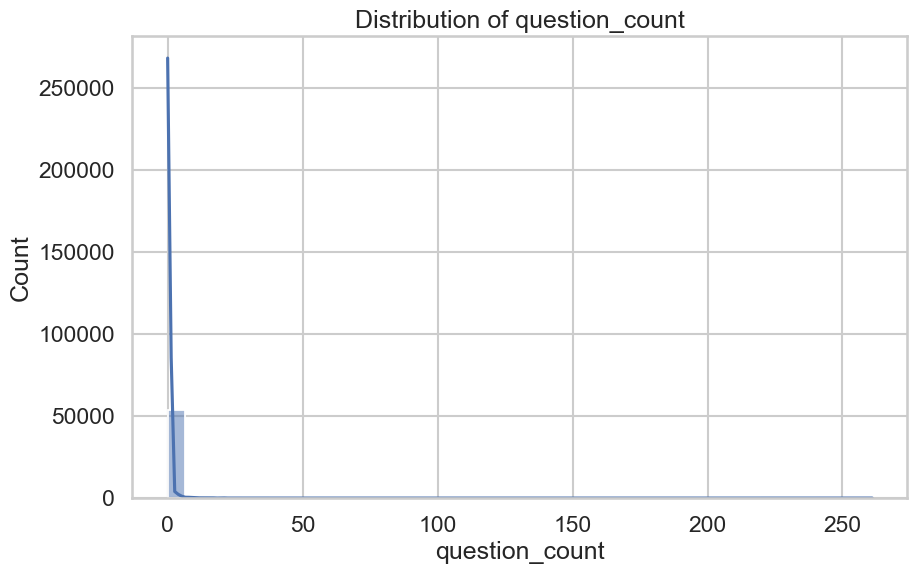

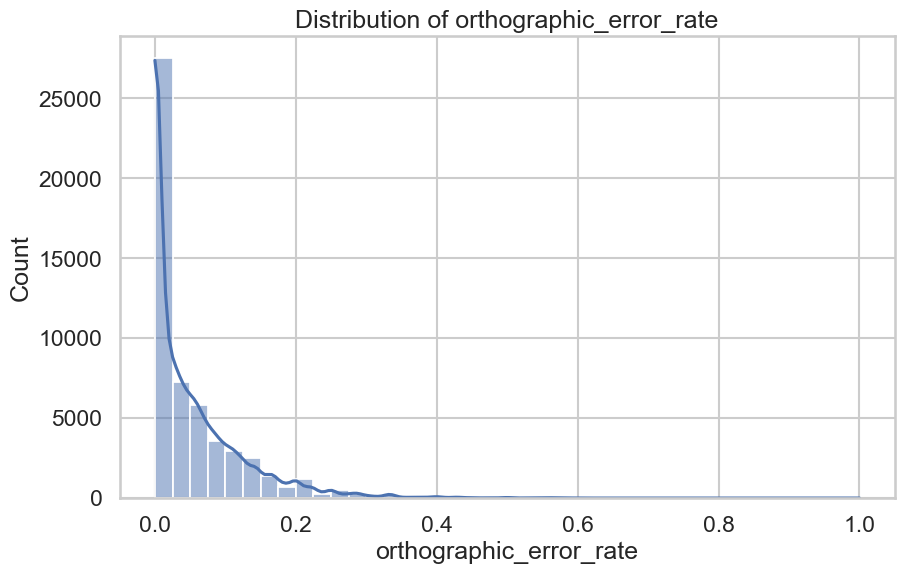

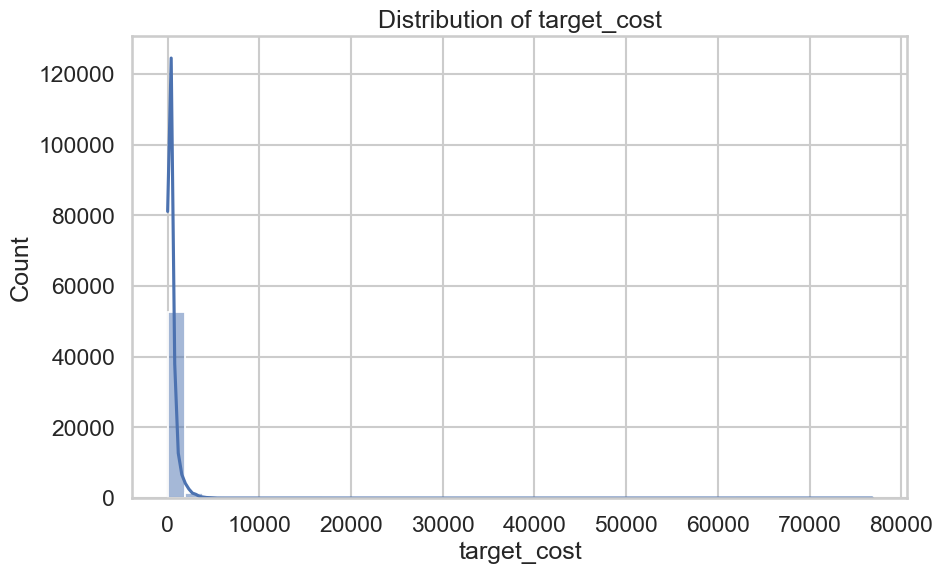

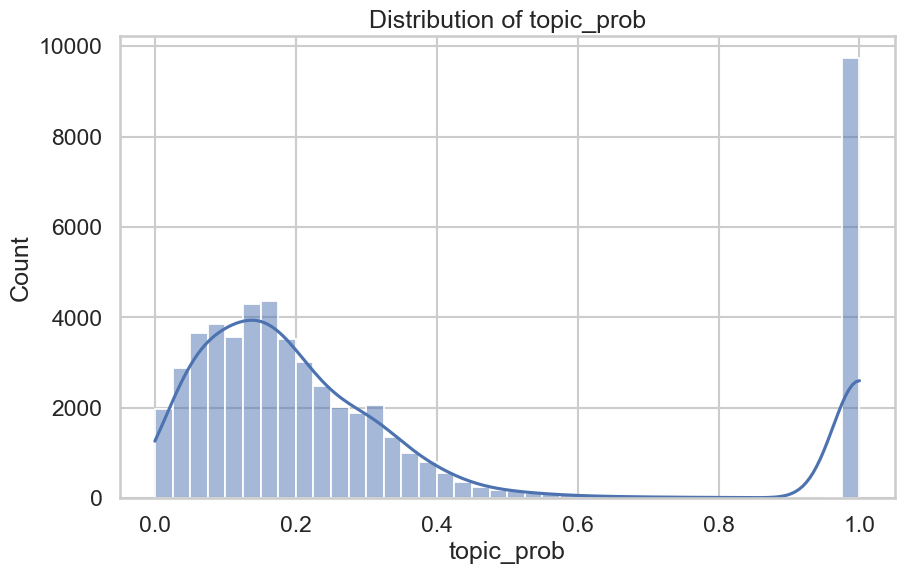

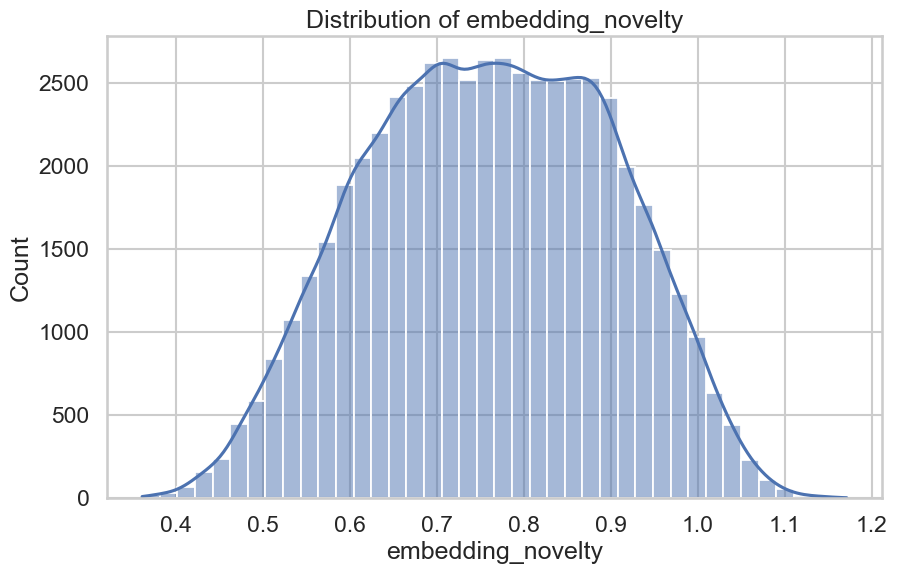

In [ ]:
# ----------------------------
# NUMERICAL DISTRIBUTIONS
# ----------------------------

for col in numeric_features:
    plt.figure()
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

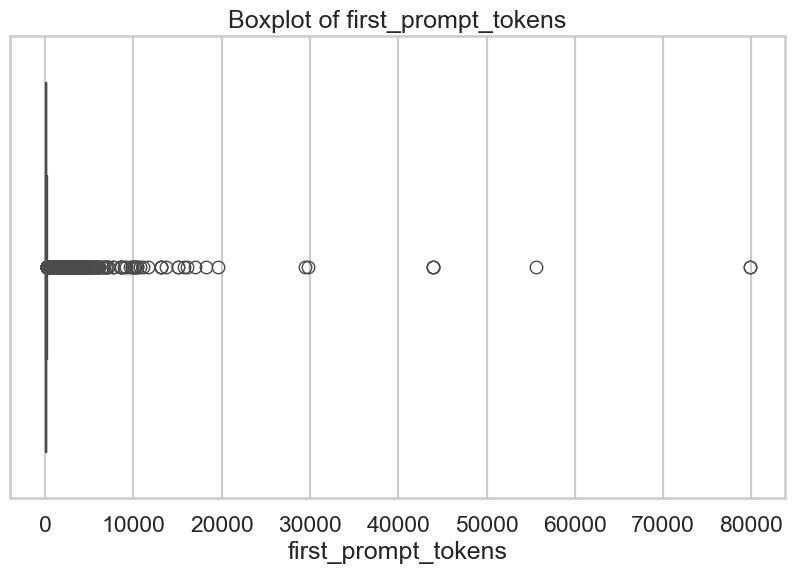

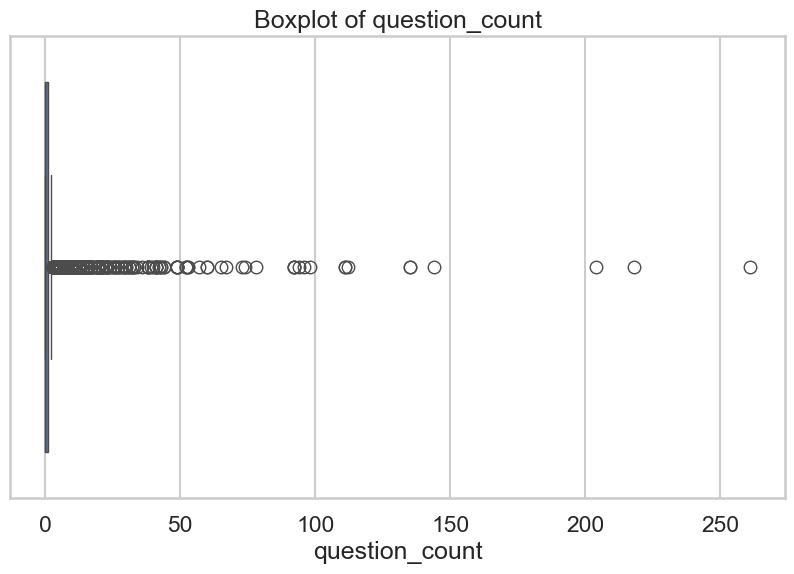

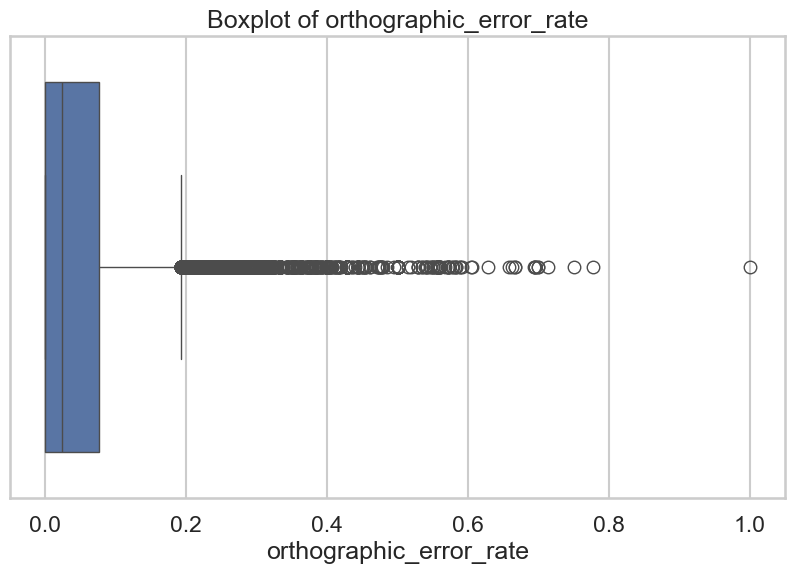

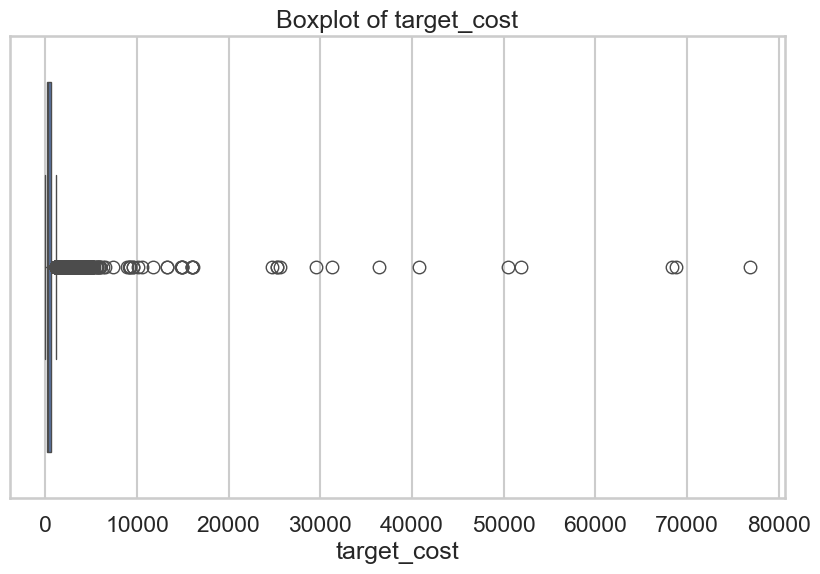

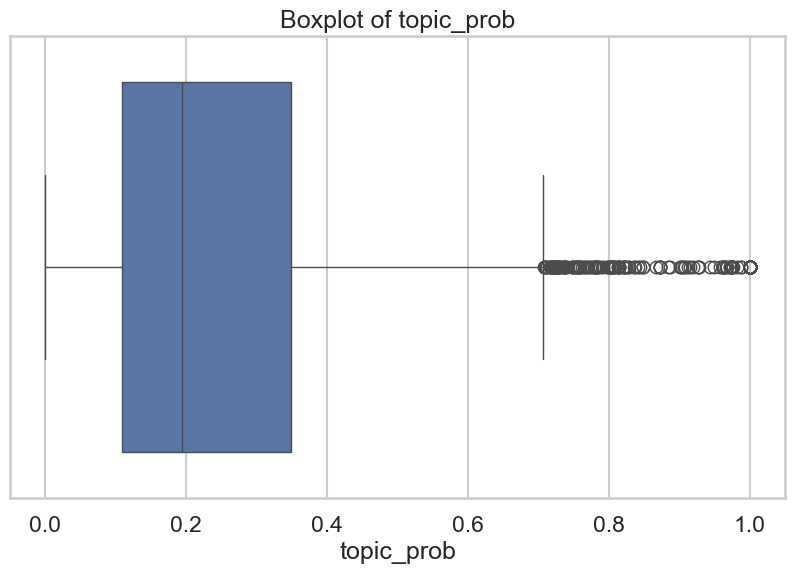

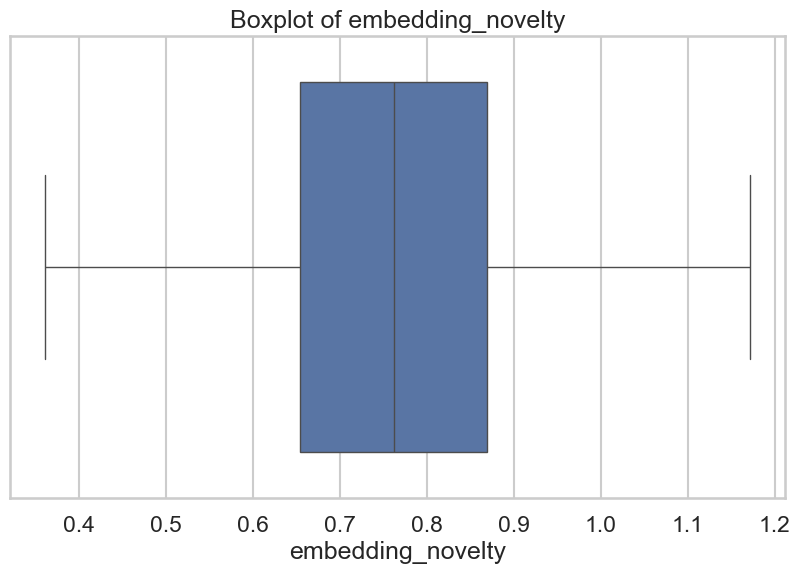

In [ ]:
# ----------------------------
# NUMERICAL BOXPLOTS
# ----------------------------

for col in numeric_features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## Categorical Distributions

This section summarizes the main binary and categorical prompt-level features. The goal is to understand how common different instruction styles, prompt styles, and task types are across the dataset.

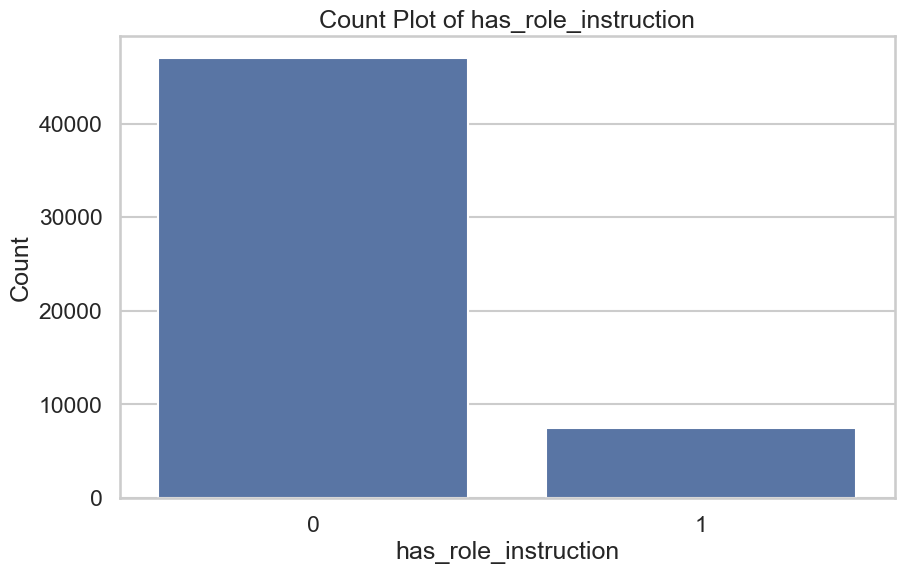

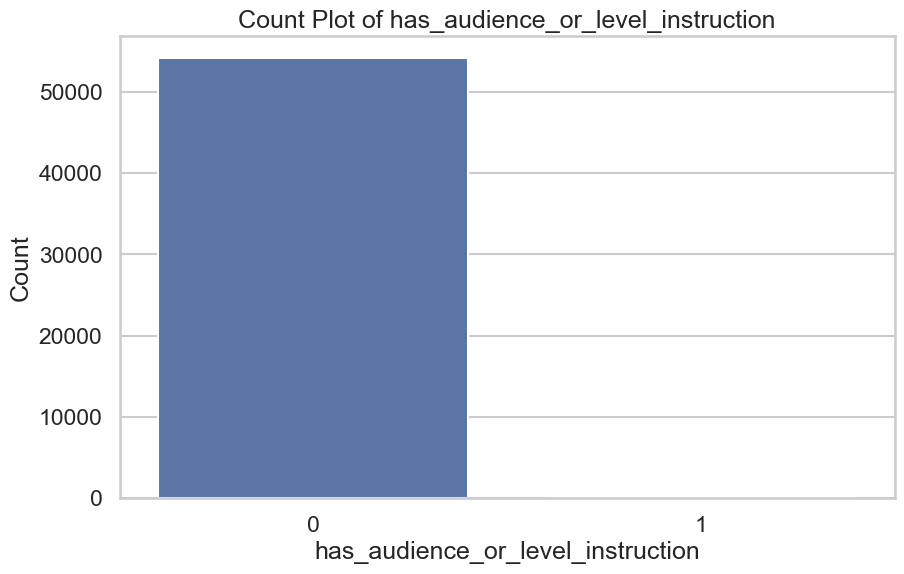

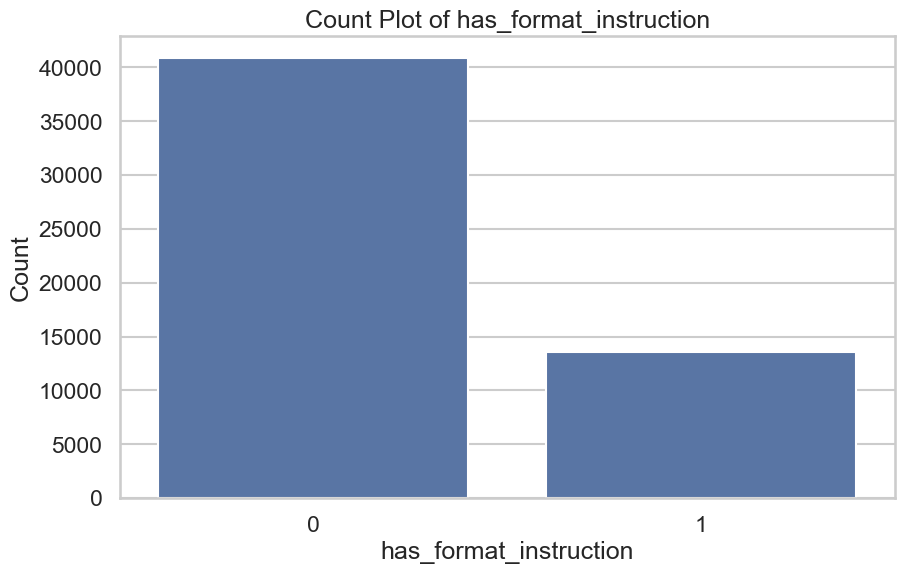

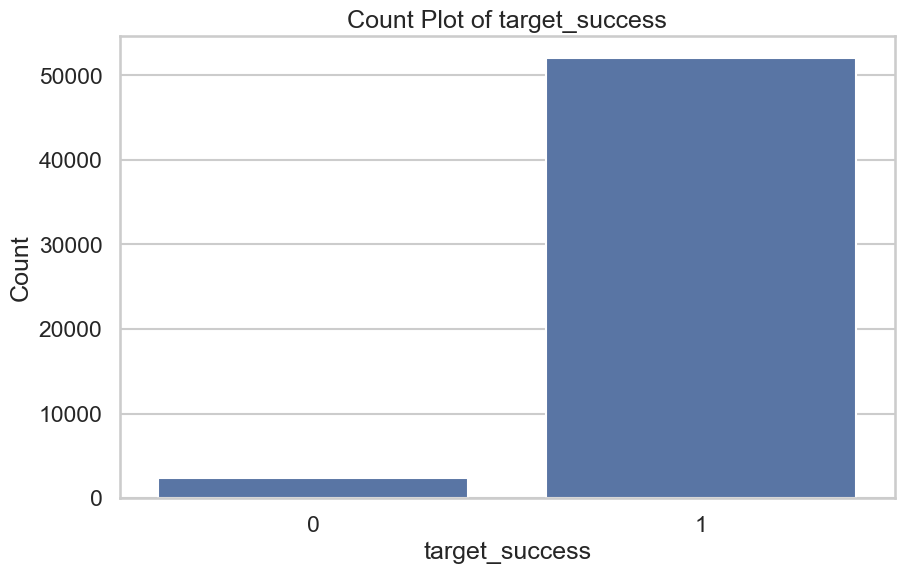

In [ ]:
# ----------------------------
# BINARY FEATURES
# ----------------------------

for col in binary_features:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

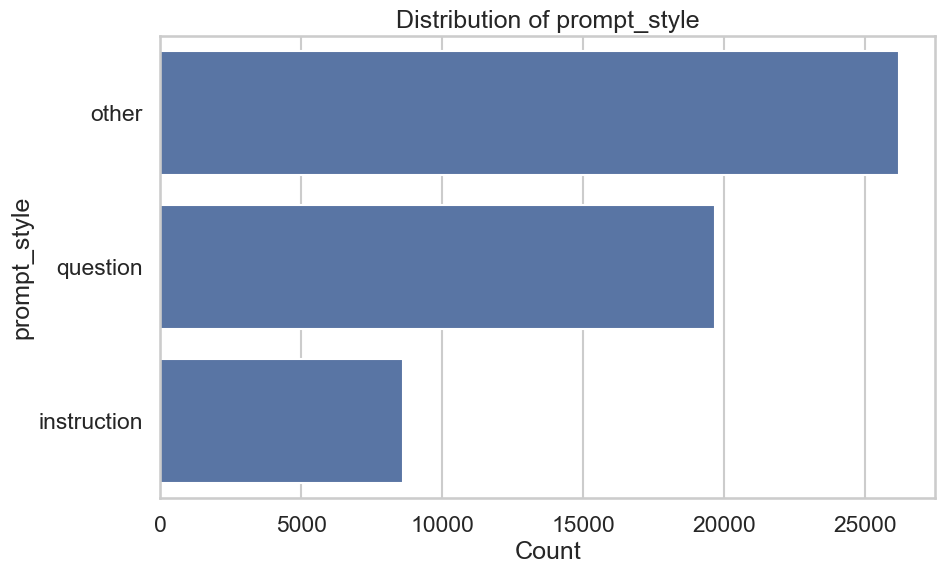

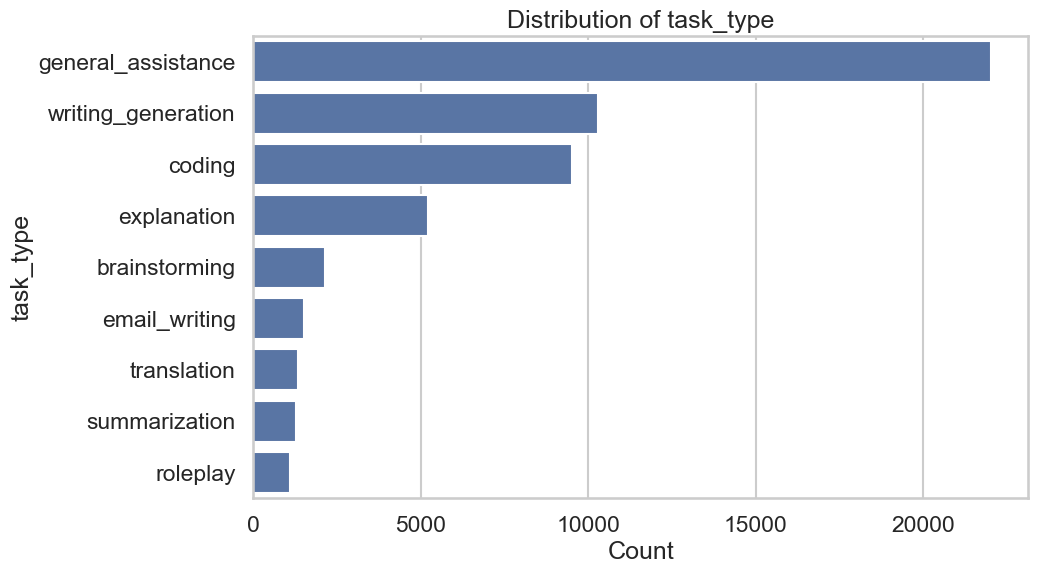

In [ ]:
# ----------------------------
# CATEGORICAL FEATURES
# ----------------------------

for col in categorical_features:
    plt.figure(figsize=(10, 6))
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

## Target Analysis

This section examines the main modelling targets. The aim is to understand target balance, target skewness, and whether simple prompt-level features show visible relationships with cost and success.

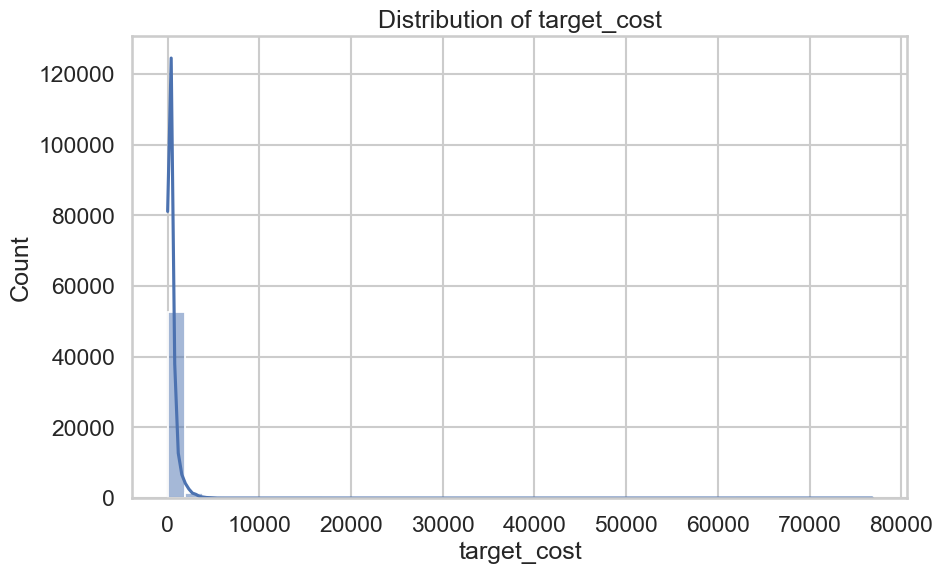

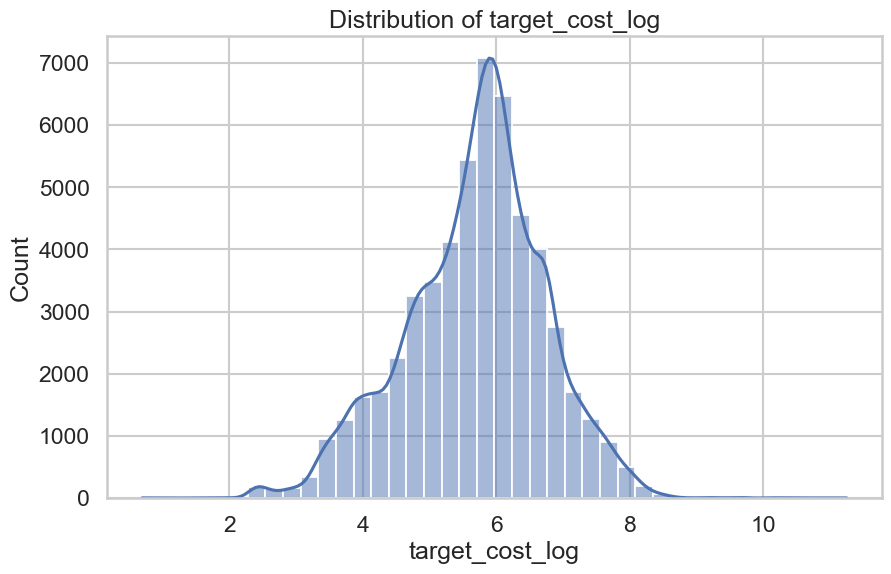

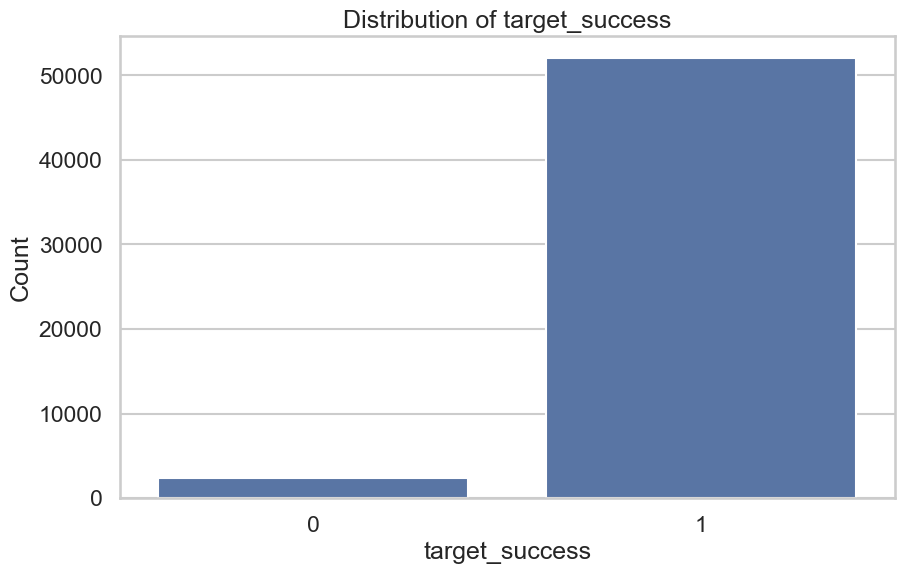

In [ ]:
# ----------------------------
# TARGET DISTRIBUTIONS
# ----------------------------

plt.figure()
sns.histplot(df["target_cost"], bins=40, kde=True)
plt.title("Distribution of target_cost")
plt.xlabel("target_cost")
plt.ylabel("Count")
plt.show()


plt.figure()
sns.histplot(df["log_target_cost"], bins=40, kde=True)
plt.title("Distribution of target_cost_log")
plt.xlabel("target_cost_log")
plt.ylabel("Count")
plt.show()


plt.figure()
sns.countplot(x=df["target_success"])
plt.title("Distribution of target_success")
plt.xlabel("target_success")
plt.ylabel("Count")
plt.show()




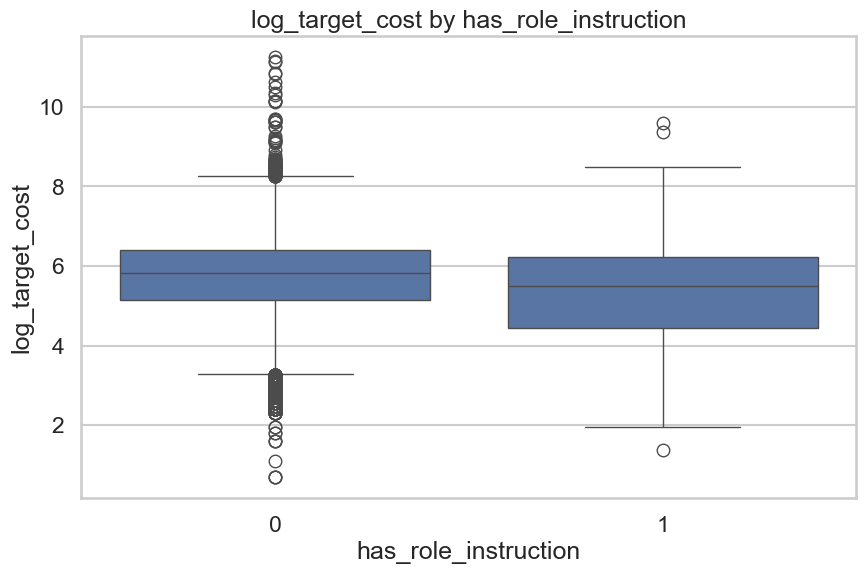

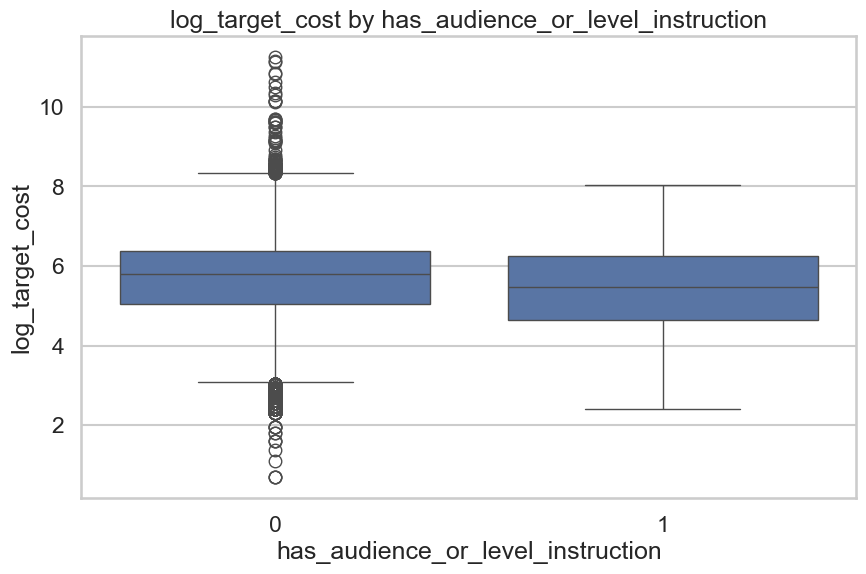

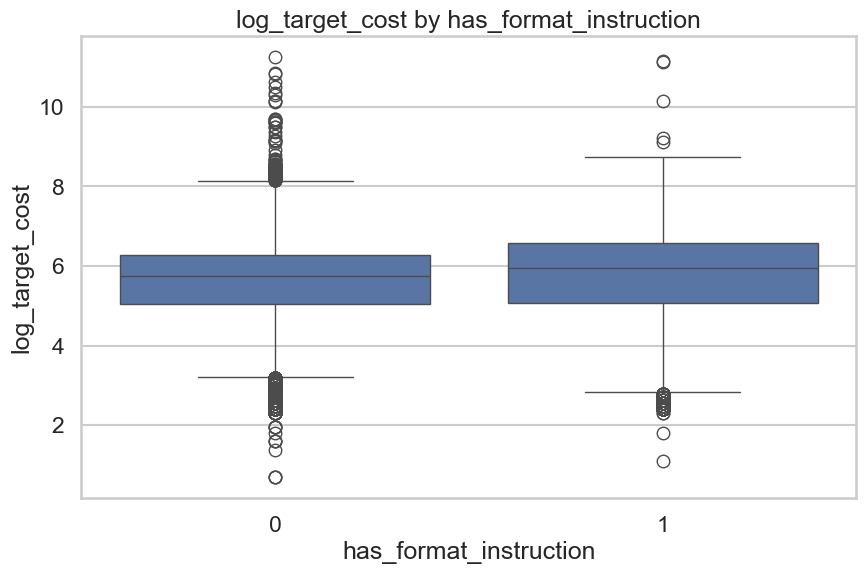

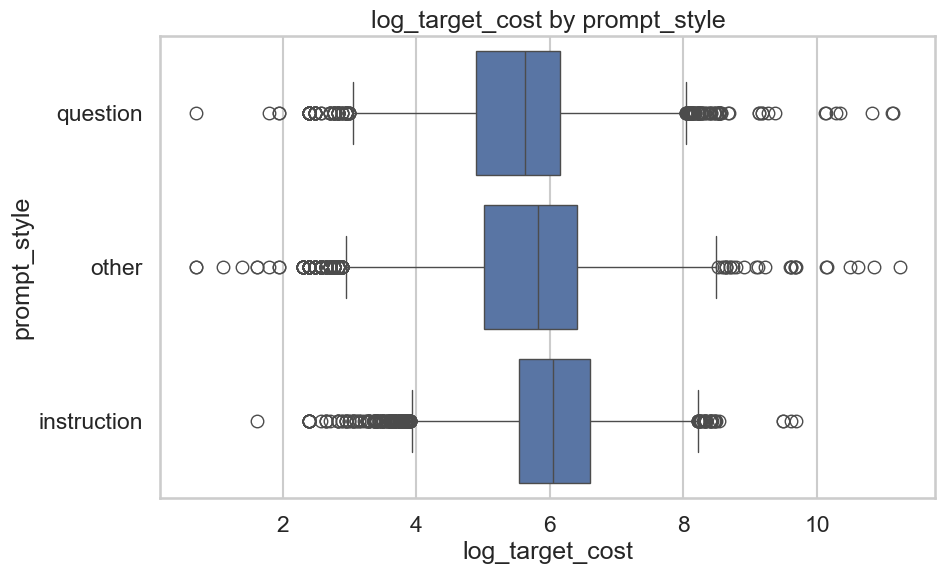

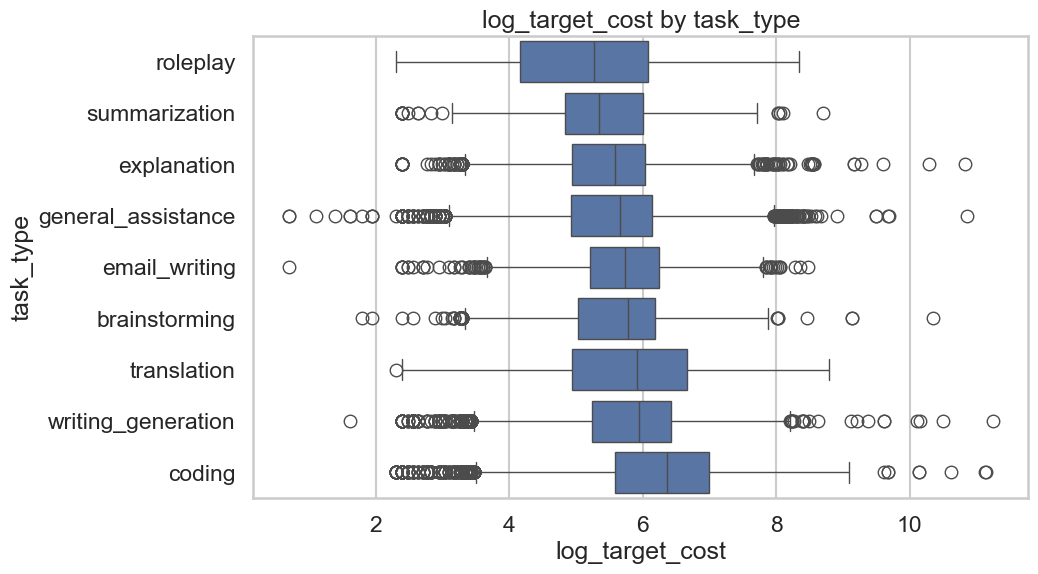

In [ ]:
# ----------------------------
# TARGET VS CENTRAL FEATURES
# ----------------------------

for col in ["has_role_instruction", "has_audience_or_level_instruction", "has_format_instruction"]:
    plt.figure()
    sns.boxplot(data=df, x=col, y="log_target_cost")
    plt.title(f"log_target_cost by {col}")
    plt.show()

for col in ["prompt_style", "task_type"]:
    plt.figure(figsize=(10, 6))
    order = df.groupby(col)["log_target_cost"].median().sort_values().index
    sns.boxplot(data=df, y=col, x="log_target_cost", order=order)
    plt.title(f"log_target_cost by {col}")
    plt.show()

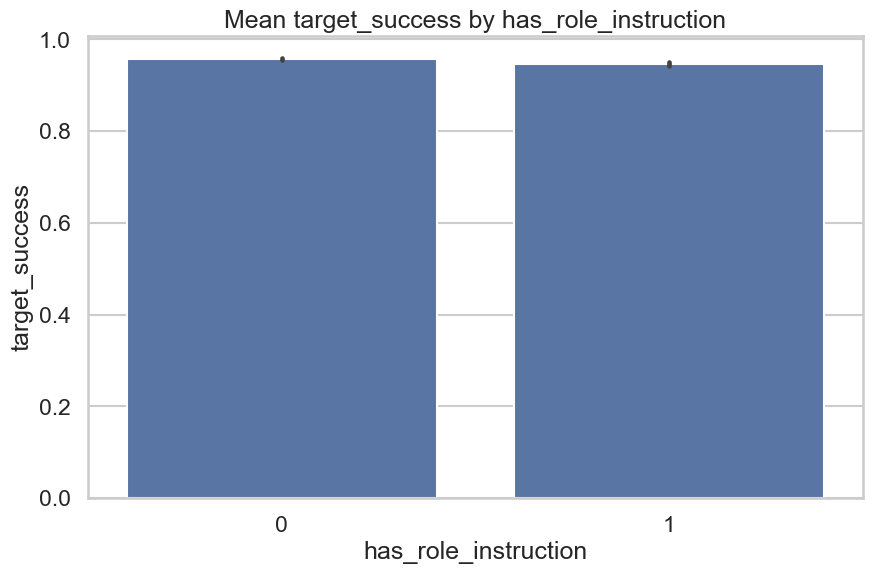

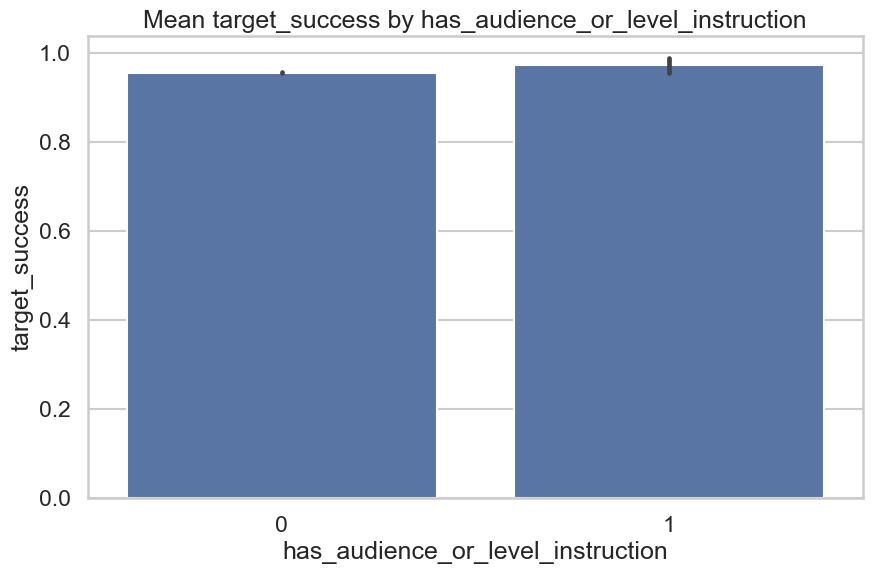

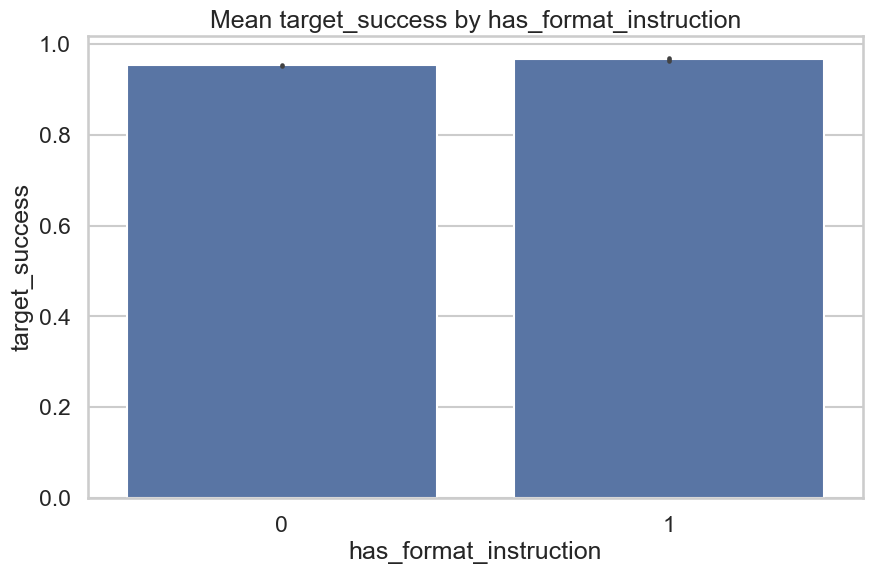

In [ ]:
for col in ["has_role_instruction", "has_audience_or_level_instruction", "has_format_instruction"]:
    sns.barplot(data=df, x=col, y="target_success", estimator=np.mean)
    plt.title(f"Mean target_success by {col}")
    plt.show()

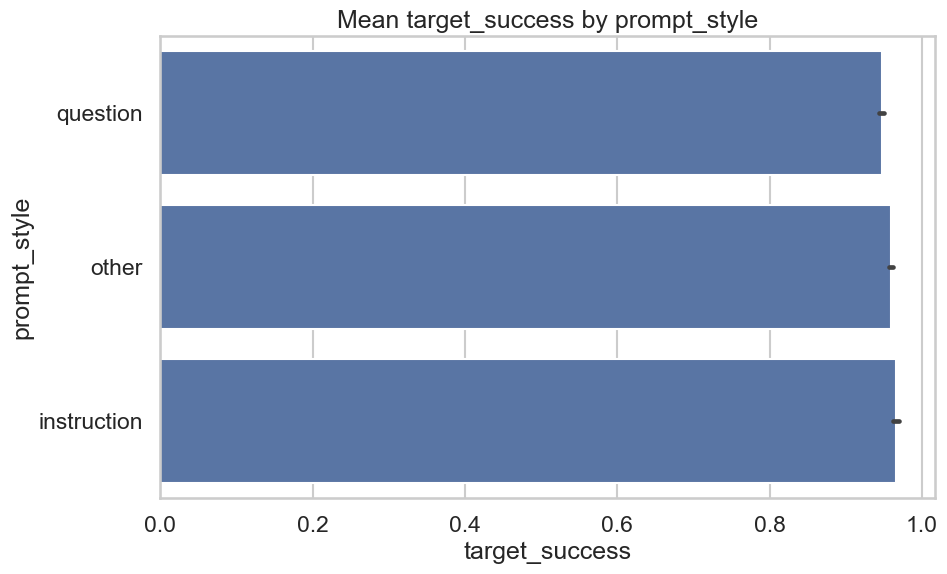

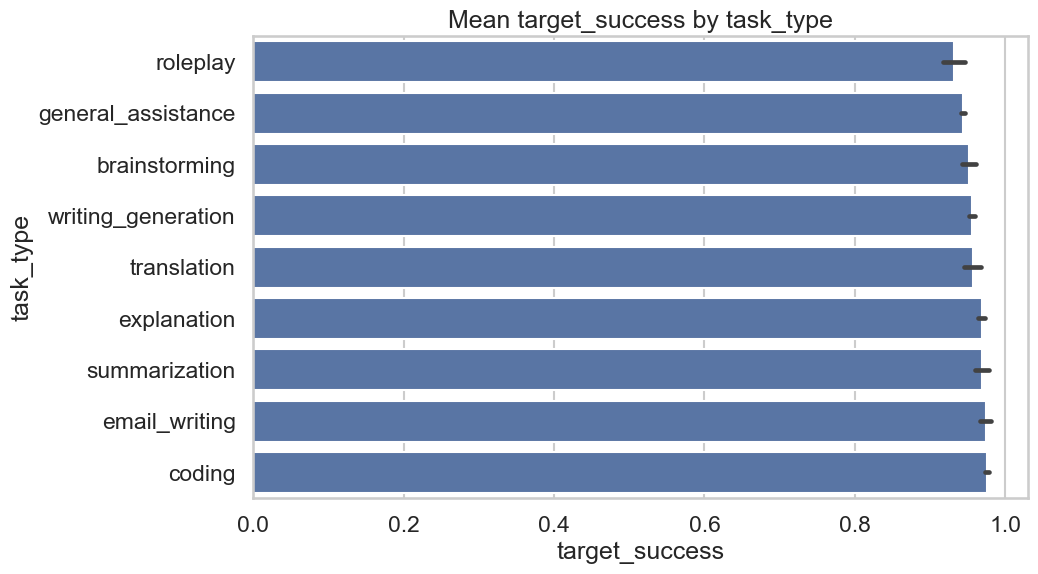

In [ ]:
for col in ["prompt_style", "task_type"]:
    order = df.groupby(col)["target_success"].mean().sort_values().index
    sns.barplot(data=df, y=col, x="target_success", order=order, estimator=np.mean)
    plt.title(f"Mean target_success by {col}")
    plt.show()

In [ ]:
pd.crosstab(df["prompt_style"], df["target_success"], normalize="index")

target_success,0,1
prompt_style,,
instruction,0.03,0.97
other,0.04,0.96
question,0.05,0.95


## Topic Analysis

`topic_label` is a high-cardinality feature and is therefore analyzed separately. Instead of reviewing all categories, the notebook focuses on the most frequent topics and the long-tail structure.

In [ ]:
# ----------------------------
# TOPIC LABEL ANALYSIS
# ----------------------------

topic_counts = df["topic_label"].value_counts()

print("Unique topics:", topic_counts.shape[0])
display(topic_counts.head(20))
print("Other topics:", topic_counts.iloc[20:].sum())

Unique topics: 107


topic_label
-1_like_data_use_write_time                  27958
0_dan_chatgpt_mode_prompt_developer           6786
1_game_story_character_player_characters      2197
2_const_react_js_gt_function                  1483
3_singleton_python_int_return_code             943
4_tax_financial_fund_bitcoin_market            782
5_model_csv_image_train_data                   728
6_gt_null_select_table_gt gt                   698
7_trip_itinerary_visit_places_day              534
8_piano_music_song_album_left hand             519
9_000_minutes_total_hours_did                  430
10_fa_pregnancy_patients_ct_drug               362
11_happiness_meditation_life_people_happy      350
12_god_bible_jesus_rel_biblical                344
14_enable_audio_video_import_speech            334
13_request_status_api_def_import               334
15_recipe_chicken_ingredients_add_cook         308
16_div_div div_span_class_li                   303
17_email_emails_cold_write email_friday        276
18_git_github_commi

Other topics: 8506


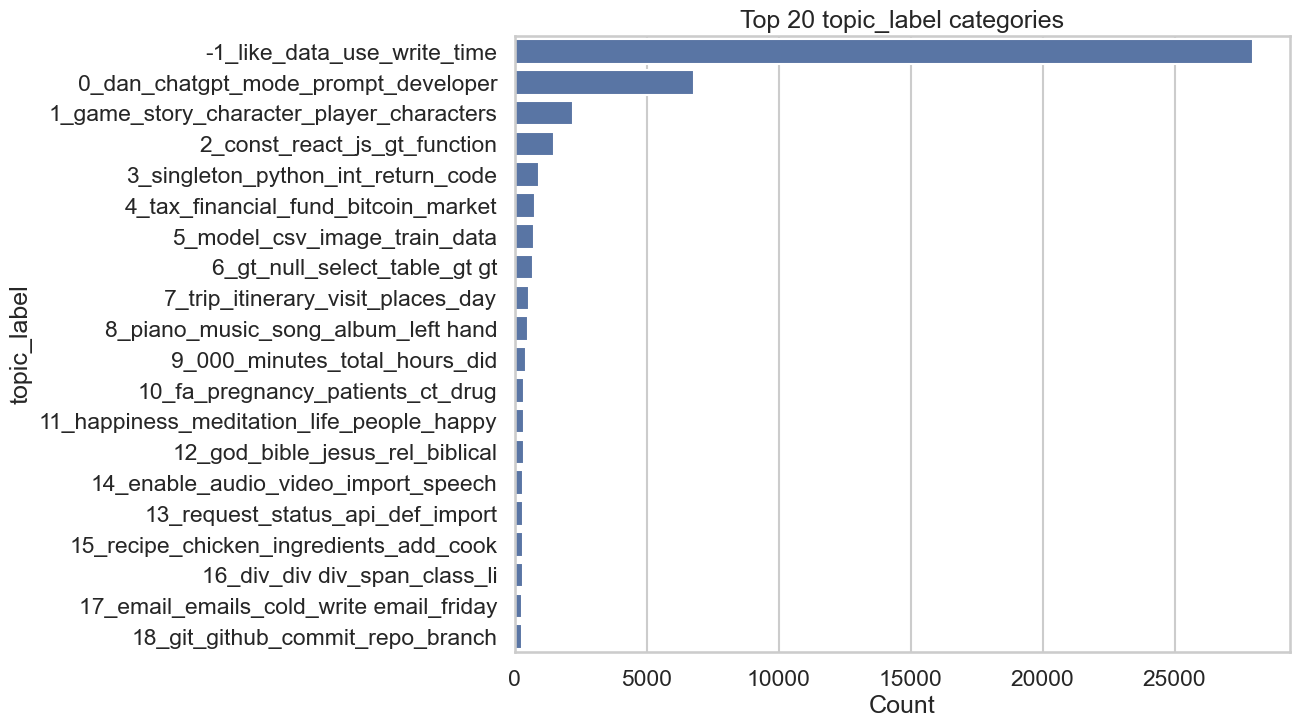

In [ ]:
# ----------------------------
# TOP TOPICS PLOT
# ----------------------------

top_20_topics = topic_counts.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_topics.values, y=top_20_topics.index)
plt.title("Top 20 topic_label categories")
plt.xlabel("Count")
plt.ylabel("topic_label")
plt.show()

## EDA Takeaways

This final section summarizes the main findings from the audit and the exploratory analysis. It should highlight important feature behaviors, modelling implications, class imbalances, skewed targets, and risks such as redundancy or outliers.

In [ ]:
# ----------------------------
# EDA NOTES
# ----------------------------

eda_notes = [
    "Major skewness patterns in numeric features.",
    "Target_cost is strongly right-skewed.",
    "target_success is imbalanced."]

for note in eda_notes:
    print("-", note)

- Major skewness patterns in numeric features.
- Target_cost is strongly right-skewed.
- target_success is imbalanced.


In [107]:
df[["first_prompt", "orthographic_error_rate"]].sort_values(
    by="orthographic_error_rate",
    ascending=False
).head(50)

,first_prompt,orthographic_error_rate
19307,帮我写一个利用convlstm进行时间序列图像的目标检测 ，输入序列图像，输出目标检测结果,1.00
35311,czy znasz narzędzie do monitorowania infrastruktury IT - Splunk?,0.78
27036,what is this language : Dsvmh ivhvhhrxv iudqfhv xq hpsorl hu qrxv vhqv. \n\nFvezi revirippzi rdlevzi pzi irksvim ri ...,0.75
44735,"Please continue from ""Answers:\n .\t10799\tIN\tDNSKEY\t256 3 8 AwEAAbOvDzr7VH3mFGu+gV8cXsB9Np/KLK0Z/AGLW8c+gusI6TFN...",0.71
8037,"1 / 1Jestem Product Designerem. Mam ponad 10-letnie doświadczenie, ale w mojej pracy często zmagam się z wieloma tru...",0.70
5873,"1 / 1Jestem Product Designerem. Mam ponad 10-letnie doświadczenie, ale w mojej pracy często zmagam się z wieloma tru...",0.70
40045,Tarvitsen luentomateriaalin yhdelle 90 minuuttiselle luennolle. Kurssi on tietorakenteet ja algoritmit. Käsittelemme...,0.70
36362,Tarvitsen luentomateriaalin yhdelle 90 minuuttiselle luennolle. Kurssi on tietorakenteet ja algoritmit. Käsittelemme...,0.70
49221,Tarvitsen luentomateriaalin yhdelle 90 minuuttiselle luennolle. Kurssi on tietorakenteet ja algoritmit. Käsittelemme...,0.70
6325,Pomożesz mi napisać notatkę z zajęć o innowacji oraz systemach i strategiach zarządzania innowacją. Notatka powinna ...,0.69
